# ERA5 Reanalysis Data Workflow - Mean Precipitation

---

## Overview

[ERA5](https://confluence.ecmwf.int/display/CKB/ERA5) is ECMWF's fifth-generation
global atmospheric reanalysis, covering 1940–present at roughly 0.25° (~31 km)
resolution. GDEX hosts ERA5 as dataset [`d633000`](https://gdex.ucar.edu/datasets/d633000/).

In this notebook we access ERA5 **precipitation** directly from GDEX's
Analysis-Ready, Cloud-Optimized (ARCO) **Zarr** stores — no bulk downloads and no
intake-ESM catalog. We then make a quick map and a zonal-mean diagnostic.

1. Discover ERA5 ARCO precipitation variables on GDEX through the API
2. Open a cloud-optimized Zarr store directly with `xarray`
3. Subset a global precipitation field for a chosen time
4. Convert units and visualize precipitation on a map
5. Compute a simple diagnostic (zonal-mean precipitation)

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Introduction to ARCO/Zarr on GDEX](../services/zarr_intro.ipynb) | Necessary | Opening Zarr stores on GDEX |
| [xarray](https://docs.xarray.dev) | Necessary | Labeled N-D arrays |
| [Cartopy](https://scitools.org.uk/cartopy) | Necessary | Mapping |
| [Dask](https://dask.org) | Helpful | Larger-than-memory subsets |
| [ARCO ERA5 Cookbook](https://projectpythia.org/ARCO-ERA5-cookbook/) | Helpful | Companion cookbook on the ARCO ERA5 dataset |

- **Time to learn**: 30 minutes

---

## Imports

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## ERA5 on GDEX

GDEX publishes selected datasets in **ARCO** form — chunked, indexed Zarr stores or virtual zarr stores 
that support fast remote, partial reads. For ERA5 (`d633000`), the precipitation
fields are exposed as [**kerchunk**](https://fsspec.github.io/kerchunk/) reference
files: small JSON "indexes" that point into the underlying archive and let
`xarray` treat the whole collection as a single Zarr store.

The practical upshot: we open the data lazily over HTTPS and only the bytes we
actually use get transferred — no need to download full files.


| Dataset ID | Description |
| --- | --- |
| `d633000` | ERA5 reanalysis on the 0.25° lat–lon grid — surface, pressure-level, and forecast/mean-flux fields (precipitation lives here) |
| `d633006` | ERA5 reanalysis **model-level** data on the native ~0.28° grid |

## Loading the ERA5 precipitation reference file

This notebook assumes you've already identified the kerchunk reference file for
the variable you want. There are a few ways to find it:

- **Programmatically**, through the GDEX API — see the [API notebooks](../services/api_intro.ipynb)
  and the ARCO discovery endpoints (`has_arco`, `search_arco_vars`) demonstrated in
  [Introduction to ARCO/Zarr on GDEX](../services/zarr_intro.ipynb).
- **Via the dataset's intake-ESM catalog** — `d633000` ships one at
  [`d633000-https.json`](https://data.gdex.ucar.edu/d633000/catalogs/d633000-https.json),
  which lets you search variables and look up their reference files. Note this is
  available for *this* dataset but **not all** GDEX datasets have a catalog.
- **Interactively**, by searching the [`d633000` dataset homepage](https://gdex.ucar.edu/datasets/d633000/).


Here we use **MTPR** — *Mean total precipitation rate*, a surface mean-flux field
combining convective and large-scale precipitation. Its reference file is:

In [2]:
reference_url = ("https://data.gdex.ucar.edu/d633000/kerchunk/meanflux/Mean_total_precipitation_rate-osdf.json")
reference_url

'https://data.gdex.ucar.edu/d633000/kerchunk/meanflux/Mean_total_precipitation_rate-osdf.json'

In [3]:
%%time
ds = xr.open_dataset(reference_url, engine ='kerchunk')
ds

CPU times: user 1.04 s, sys: 154 ms, total: 1.19 s
Wall time: 6.04 s


<xarray.Dataset> Size: 3TB
Dimensions:                (forecast_initial_time: 61666, forecast_hour: 12,
                            latitude: 721, longitude: 1440)
Coordinates:
  * forecast_initial_time  (forecast_initial_time) datetime64[ns] 493kB 1940-...
  * forecast_hour          (forecast_hour) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude               (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude              (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    MTPR                   (forecast_initial_time, forecast_hour, latitude, longitude) float32 3TB ...
    utc_date               (forecast_initial_time) int32 247kB ...
Attributes:
    CONVERSION_DATE:      Wed Nov  2 10:03:48 MDT 2022
    CONVERSION_PLATFORM:  Linux r3i0n28 4.12.14-95.51-default #1 SMP Fri Apr ...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.0.3 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.8.1
    history:              Wed Nov  2 10:03:57 2022: ncks -4 --ppc default=7 e...

### Inspecting the data

`MTPR` is organized by `forecast_initial_time` (twice-daily forecast base times,
1940–2024) and `forecast_hour` (1–12 hours into each forecast), on a 0.25°
latitude–longitude grid. Values are a mean rate in `kg m⁻² s⁻¹`.

In [4]:
mtpr = ds["MTPR"]
mtpr

<xarray.DataArray 'MTPR' (forecast_initial_time: 61666, forecast_hour: 12,
                          latitude: 721, longitude: 1440)> Size: 3TB
[768289294080 values with dtype=float32]
Coordinates:
  * forecast_initial_time  (forecast_initial_time) datetime64[ns] 493kB 1940-...
  * forecast_hour          (forecast_hour) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude               (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude              (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Attributes: (12/14)
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7
    ecmwf_local_table:                                  235
    ecmwf_parameter:                                    55
    grid_specification:                                 0.25 degree x 0.25 de...
    long_name:                                          Mean total precipitat...
    maximum_value:                                      0.017209529876708984
    ...                                                 ...
    rda_dataset:                                        d633000
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    short_name:                                         mtpr
    units:                                              kg m**-2 s**-1

### Selecting a precipitation field

We pick a single field: the forecast initialized on 15 July 2023 at 06:00 UTC,
six hours in. Since 1 kg m⁻² s⁻¹ ≈ 86400 mm/day, we convert to mm/day for an
interpretable map.

In [9]:
precip = mtpr.sel(forecast_initial_time="2023-07-15T06:00:00").isel(forecast_hour=6)

precip_mmday = precip * 86400
precip_mmday.attrs["units"] = "mm/day"
precip_mmday.attrs["long_name"] = "Mean total precipitation rate"

## Visualizing global precipitation

A `PlateCarree` map with coastlines puts the field in geographic context. Calling
`.plot()` triggers the lazy read of just this one slice.

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


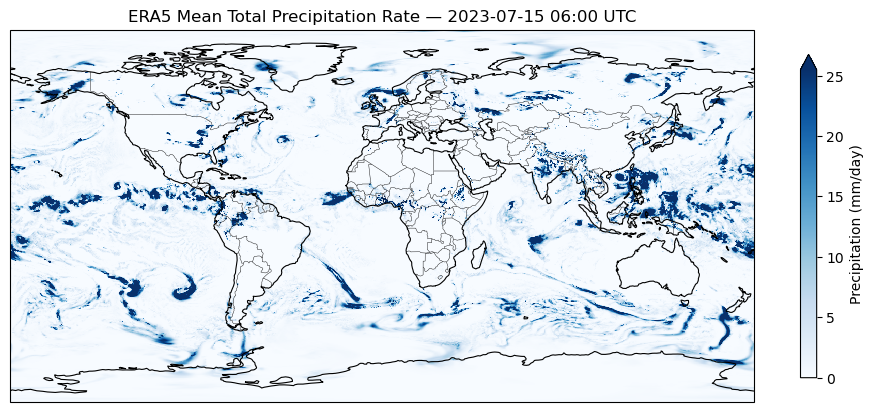

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

precip_mmday.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x="longitude",
    y="latitude",
    cmap="Blues",
    robust=True,
    cbar_kwargs={"label": "Precipitation (mm/day)", "shrink": 0.7},
)

ax.coastlines(color="black", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_title("ERA5 Mean Total Precipitation Rate — 2023-07-15 06:00 UTC")
plt.show()

---

## Summary

We opened ERA5 mean total precipitation rate from GDEX's ARCO Zarr store, selected
a single forecast field, converted it to mm/day, and visualized it as a global map
and a zonal-mean profile.

### What's next?

Continue to the [JRA-3Q Reanalysis Workflow](jra3q.ipynb), which applies a similar
GDEX access pattern to another global reanalysis.

## Resources and references

- [ERA5 documentation (ECMWF)](https://confluence.ecmwf.int/display/CKB/ERA5)
- [GDEX ERA5 dataset (`d633000`)](https://gdex.ucar.edu/datasets/d633000/)
- [Original GDEX ERA5 precipitation example](https://ncar.github.io/gdex-examples/era5-precipitation/)
- [ARCO ERA5 Cookbook (Project Pythia)](https://projectpythia.org/ARCO-ERA5-cookbook/)